# Telecom Complaint Intelligence — Analysis & Visualisations

**Run `python main.py` before opening this notebook.**
All heavy lifting is done by the pipeline. This notebook only loads processed artefacts and visualises results.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

from src.utils import load_config, build_fcc_summary, build_youtube_summary, merge_summaries
from src.model import load_artifact

cfg   = load_config('../config.yaml')
paths = cfg['paths']

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('Setup complete.')

Setup complete.


## 1  Load Processed Data

In [2]:
df       = pd.read_csv(f"../{paths['cleaned_fcc_data']}", parse_dates=['ticket_created','date_created'])
comments = pd.read_csv(f"../{paths['comments_output']}")

print('FCC shape      :', df.shape)
print('Comments shape :', comments.shape)
print()
print('FCC columns    :', list(df.columns))
print('Comment columns:', list(comments.columns))

FCC shape      : (3304743, 9)
Comments shape : (62618, 14)

FCC columns    : ['id', 'ticket_created', 'date_created', 'issue_type', 'method', 'issue', 'city', 'state', 'zip']
Comment columns: ['comment', 'comment_text', 'tokens', 'comment_length', 'comment_word_count', 'sentiment_score', 'sentiment_label', 'issue_type', 'network_freq', 'internet_freq', 'signal_freq', 'slow_freq', 'disconnect_freq', 'topic_cluster']


## 2  FCC Data — Statistical Summary

In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Numeric Summary ===')
df.describe()

=== Missing Values ===
id                0
ticket_created    0
date_created      0
issue_type        0
method            0
issue             0
city              0
state             0
zip               0
dtype: int64

=== Numeric Summary ===


,id,zip
count,3.304743e+06,3.304743e+06
mean,4.074723e+06,5.117955e+04
std,2.534391e+06,3.027298e+04
min,5.340000e+02,0.000000e+00
25%,1.815207e+06,2.702800e+04
50%,3.787690e+06,4.654400e+04
75%,6.483173e+06,7.990200e+04
max,8.548557e+06,9.999900e+04


## 3  Top 10 Complaint Categories

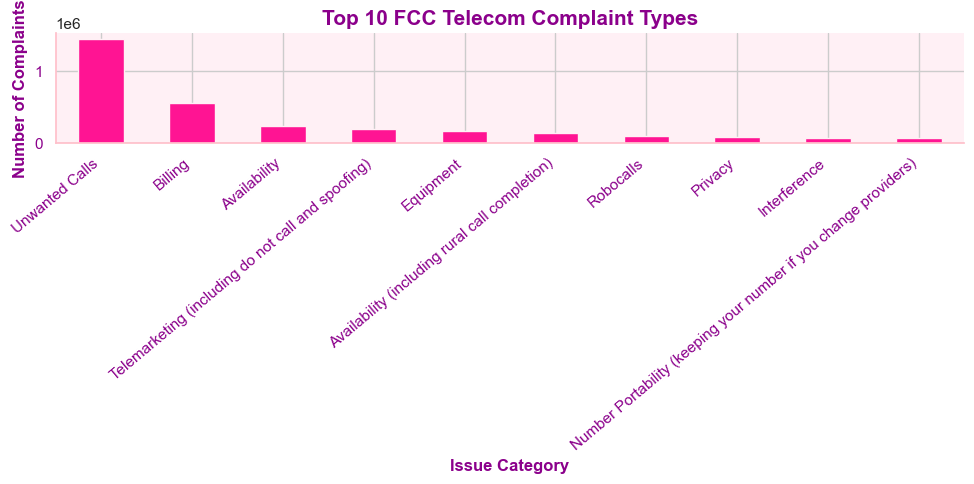

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
df['issue'].value_counts().head(10).plot(
    kind='bar', 
    ax=ax, 
    color='deeppink', 
    edgecolor='lavenderblush', 
    linewidth=1
)
ax.set_title('Top 10 FCC Telecom Complaint Types', fontsize=15, fontweight='bold', color='darkmagenta')
ax.set_xlabel('Issue Category', fontsize=12, fontweight='semibold', color='darkmagenta')
ax.set_ylabel('Number of Complaints', fontsize=12, fontweight='semibold', color='darkmagenta')
plt.xticks(rotation=40, ha='right', color='darkmagenta')
plt.yticks(color='darkmagenta')
ax.set_facecolor('#FFF0F5') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('pink')
ax.spines['bottom'].set_color('pink')
plt.tight_layout()
plt.show()

## 4  Complaints by State (Top 10)

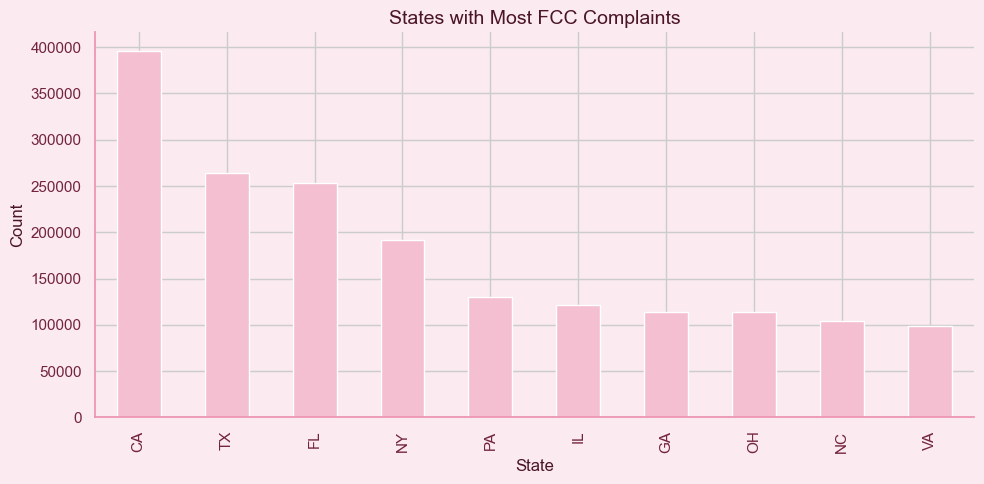

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
df['state'].value_counts().head(10).plot(kind='bar', ax=ax, color='#F4C0D1')
ax.set_title('States with Most FCC Complaints', fontsize=14, color='#4B1528')
ax.set_xlabel('State', color='#4B1528')
ax.set_ylabel('Count', color='#4B1528')
ax.tick_params(colors='#72243E')
ax.spines['bottom'].set_color('#ED93B1')
ax.spines['left'].set_color('#ED93B1')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#FBEAF0')
fig.patch.set_facecolor('#FBEAF0')
plt.tight_layout()
plt.show()

## 5  Complaints Over Time

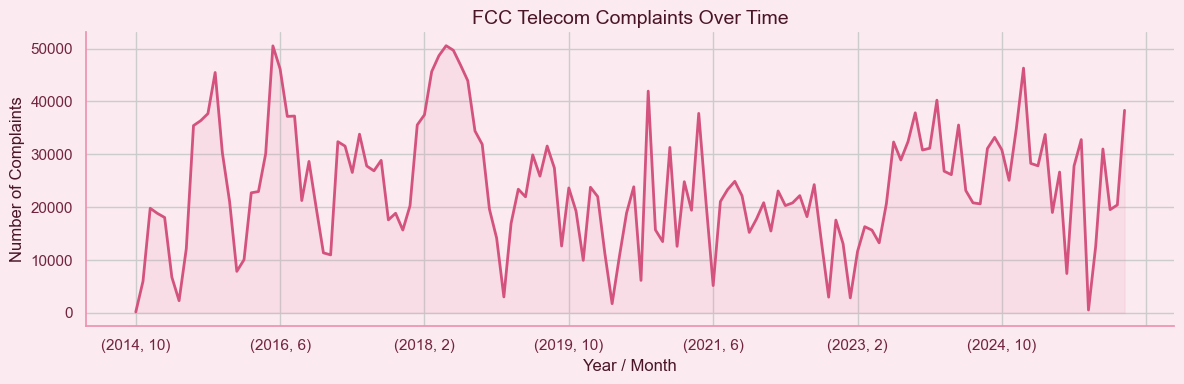

In [26]:
df['year'] = df['ticket_created'].dt.year
df['month'] = df['ticket_created'].dt.month
monthly = df.groupby(['year','month']).size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color='#D4537E', linewidth=2)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#ED93B1')
ax.set_title('FCC Telecom Complaints Over Time', fontsize=14, color='#4B1528')
ax.set_xlabel('Year / Month', color='#4B1528')
ax.set_ylabel('Number of Complaints', color='#4B1528')
ax.tick_params(colors='#72243E')
ax.spines['bottom'].set_color('#ED93B1')
ax.spines['left'].set_color('#ED93B1')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('#FBEAF0')
fig.patch.set_facecolor('#FBEAF0')
plt.tight_layout()
plt.show()

## 6  Severity Score Distribution

In [28]:
if 'severity_score' in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    df['severity_score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#F4C0D1', edgecolor='#D4537E', linewidth=0.8)
    ax.set_title('Distribution of Severity Scores (1=Minor, 5=Critical)', fontsize=13, color='#4B1528')
    ax.set_xlabel('Severity Score', color='#4B1528')
    ax.set_ylabel('Count', color='#4B1528')
    ax.tick_params(colors='#72243E')
    ax.spines['bottom'].set_color('#ED93B1')
    ax.spines['left'].set_color('#ED93B1')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#FBEAF0')
    fig.patch.set_facecolor('#FBEAF0')
    plt.tight_layout()
    plt.show()

    print('Class balance:')
    print(df['severity_score'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

## 7  Pain Level Distribution (Class Balance Check)

In [ ]:
if 'pain_level' in df.columns:
    df['pain_level'] = df['pain_level'].astype(str)
    counts = df['pain_level'].value_counts()
    counts = counts.reindex(['Low', 'Medium', 'High'])

    fig, ax = plt.subplots(figsize=(6, 4))
    counts.plot(kind='bar', ax=ax, color=['#FBEAF0','#F4C0D1','#D4537E'], edgecolor='#993556', linewidth=0.8)
    ax.set_title('Pain Level Class Distribution', fontsize=13, color='#4B1528')
    ax.set_ylabel('Count', color='#4B1528')
    ax.tick_params(colors='#72243E')
    ax.spines['bottom'].set_color('#ED93B1')
    ax.spines['left'].set_color('#ED93B1')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#FBEAF0')
    fig.patch.set_facecolor('#FBEAF0')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print('Class balance (%):')
    print((counts / counts.sum() * 100).round(1))

## 8  YouTube Comment EDA

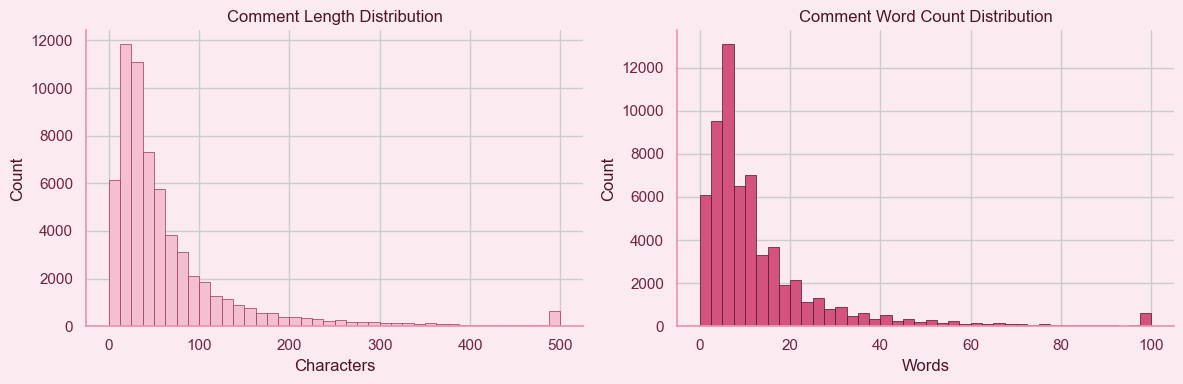

Avg comment length : 71 chars
Avg word count     : 13.9 words


In [33]:
if 'comment_length' in comments.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#FBEAF0')

    comments['comment_length'].clip(upper=500).plot(
        kind='hist', bins=40, ax=axes[0], color='#F4C0D1', edgecolor='#993556', linewidth=0.5
    )
    axes[0].set_title('Comment Length Distribution', fontsize=12, color='#4B1528')
    axes[0].set_xlabel('Characters', color='#4B1528')
    axes[0].set_ylabel('Count', color='#4B1528')
    axes[0].tick_params(colors='#72243E')
    axes[0].spines['bottom'].set_color('#ED93B1')
    axes[0].spines['left'].set_color('#ED93B1')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].set_facecolor('#FBEAF0')

    comments['comment_word_count'].clip(upper=100).plot(
        kind='hist', bins=40, ax=axes[1], color='#D4537E', edgecolor='#4B1528', linewidth=0.5
    )
    axes[1].set_title('Comment Word Count Distribution', fontsize=12, color='#4B1528')
    axes[1].set_xlabel('Words', color='#4B1528')
    axes[1].set_ylabel('Count', color='#4B1528')
    axes[1].tick_params(colors='#72243E')
    axes[1].spines['bottom'].set_color('#ED93B1')
    axes[1].spines['left'].set_color('#ED93B1')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].set_facecolor('#FBEAF0')
    plt.tight_layout()
    plt.show()
    print(f"Avg comment length : {comments['comment_length'].mean():.0f} chars")
    print(f"Avg word count     : {comments['comment_word_count'].mean():.1f} words")

## 9  YouTube Sentiment Distribution

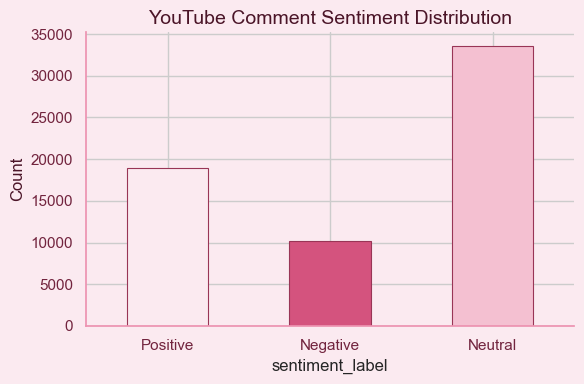

Sentiment breakdown (%):
sentiment_label
Positive    30.2
Negative    16.3
Neutral     53.5
Name: count, dtype: float64


In [34]:
if 'sentiment_label' in comments.columns:
    counts = comments['sentiment_label'].value_counts()
    counts = counts.reindex(['Positive', 'Negative', 'Neutral'])
    fig, ax = plt.subplots(figsize=(6, 4))
    counts.plot(kind='bar', ax=ax, color=['#FBEAF0','#D4537E','#F4C0D1'], edgecolor='#993556', linewidth=0.8)
    ax.set_title('YouTube Comment Sentiment Distribution', fontsize=14, color='#4B1528')
    ax.set_ylabel('Count', color='#4B1528')
    ax.tick_params(colors='#72243E')
    ax.spines['bottom'].set_color('#ED93B1')
    ax.spines['left'].set_color('#ED93B1')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#FBEAF0')
    fig.patch.set_facecolor('#FBEAF0')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print('Sentiment breakdown (%):')
    print((counts / counts.sum() * 100).round(1))

## 10  Sentiment Heatmap by Issue Type

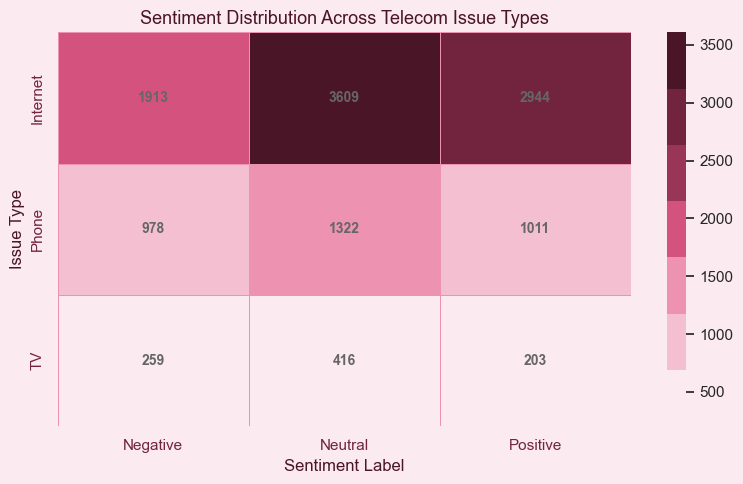

In [36]:
if 'issue_type' in comments.columns and 'sentiment_label' in comments.columns:
    pivot = comments.groupby(['issue_type','sentiment_label']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('#FBEAF0')
    sns.heatmap(
        pivot,
        annot=True,
        fmt='d',
        cmap=sns.color_palette(['#FBEAF0','#F4C0D1','#ED93B1','#D4537E','#993556','#72243E','#4B1528'], as_cmap=True),
        ax=ax,
        linewidths=0.5,
        linecolor='#ED93B1',
        annot_kws={'color':'#666666','fontsize':10,'fontweight':'bold'}
    )
    ax.set_title('Sentiment Distribution Across Telecom Issue Types', fontsize=13, color='#4B1528')
    ax.set_xlabel('Sentiment Label', color='#4B1528')
    ax.set_ylabel('Issue Type', color='#4B1528')
    ax.tick_params(colors='#72243E')
    ax.set_facecolor('#FBEAF0')
    plt.tight_layout()
    plt.show()

## 11  FCC Complaints vs YouTube Discussions

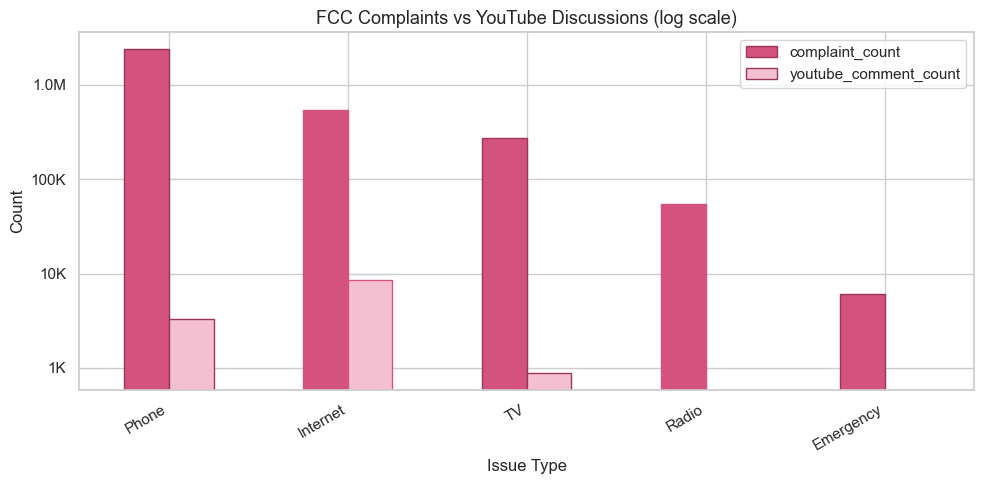

In [23]:
from matplotlib.ticker import FuncFormatter

def fmt_count(x, _):
    if x >= 1e6: return f'{x/1e6:.1f}M'
    if x >= 1e3: return f'{x/1e3:.0f}K'
    return f'{int(x):,}'

fig, ax = plt.subplots(figsize=(10, 5))
final.plot(
    x='issue_type',
    y=['complaint_count', 'youtube_comment_count'],
    kind='bar', logy=True, ax=ax,
    color=['#D4537E', '#F4C0D1'],        # dark pink, light pink
    edgecolor=['#993556', '#D4537E'],
)

ax.yaxis.set_major_formatter(FuncFormatter(fmt_count))
ax.set_title('FCC Complaints vs YouTube Discussions (log scale)', fontsize=13)
ax.set_ylabel('Count')                   # not "Log Count"
ax.set_xlabel('Issue Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12  KMeans Topic Cluster Labels

In [13]:
topic_path = Path('../models/kmeans_topic_labels.json')
if topic_path.exists():
    with open(topic_path) as f:
        topics = json.load(f)

    print('KMeans Topic Clusters — Top 10 Words Each')
    print('=' * 50)
    for cluster_id, words in topics.items():
        print(f"  Cluster {cluster_id}: {', '.join(words)}")
else:
    print('topic labels file not found — run main.py first')

KMeans Topic Clusters — Top 10 Words Each
  Cluster 0: have, and, mbps, you, the, to, in, don, ethernet, my
  Cluster 1: bhai, thank, hai, ho, thanks, you, nhi, mera, raha, nahi
  Cluster 2: hai, 5g, bhi, raha, nhi, ho, airtel, nahi, unlimited, jio
  Cluster 3: is, the, my, to, and, it, internet, in, this, speed
  Cluster 4: bro, you, thank, thanks, it, working, me, work, much, video


## 13  Random Forest — Regression Metrics

In [14]:
rf_path = Path('../models/rf_metrics.json')
if rf_path.exists():
    with open(rf_path) as f:
        rf = json.load(f)

    print('=' * 45)
    print('   RANDOM FOREST REGRESSOR — RESULTS')
    print('=' * 45)
    print(f"  R²         : {rf['R2']:.4f}")
    print(f"  MAE        : {rf['MAE']:.4f}")
    print(f"  RMSE       : {rf['RMSE']:.4f}")
    print(f"  CV R² mean : {rf['CV_R2_mean']:.4f}")
    print(f"  CV R² std  : {rf['CV_R2_std']:.4f}")
    print('=' * 45)
else:
    print('rf_metrics.json not found — run main.py first')

   RANDOM FOREST REGRESSOR — RESULTS
  R²         : 0.6787
  MAE        : 0.2773
  RMSE       : 0.5263
  CV R² mean : 0.6787
  CV R² std  : 0.0022


## 14  Feature Importance — Random Forest

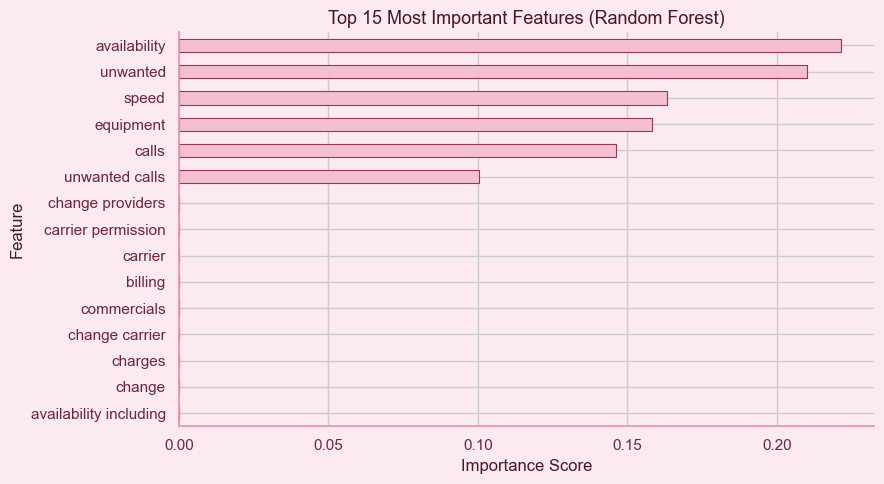

In [37]:
fi_path = Path('../models/rf_feature_importance.csv')
if fi_path.exists():
    fi = pd.read_csv(fi_path)
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('#FBEAF0')
    fi.sort_values('importance').plot(
        x='feature', y='importance',
        kind='barh', ax=ax, color='#F4C0D1',
        edgecolor='#993556', linewidth=0.8, legend=False
    )
    ax.set_title('Top 15 Most Important Features (Random Forest)', fontsize=13, color='#4B1528')
    ax.set_xlabel('Importance Score', color='#4B1528')
    ax.set_ylabel('Feature', color='#4B1528')
    ax.tick_params(colors='#72243E')
    ax.spines['bottom'].set_color('#ED93B1')
    ax.spines['left'].set_color('#ED93B1')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('#FBEAF0')
    plt.tight_layout()
    plt.show()
else:
    print('rf_feature_importance.csv not found — run main.py first')

## 15  XGBoost — Accuracy & Classification Report

In [16]:
xgb_path = Path('../models/xgb_metrics.json')
if xgb_path.exists():
    with open(xgb_path) as f:
        xgb = json.load(f)

    print('=' * 45)
    print('      XGBOOST CLASSIFIER — RESULTS')
    print('=' * 45)
    print(f"  Accuracy : {xgb['accuracy']:.4f}")
    print()

    report = xgb['report']
    labels = [k for k in report if k not in ('accuracy','macro avg','weighted avg')]
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print('-' * 50)
    for label in labels:
        r = report[label]
        print(f"{label:<12} {r['precision']:>10.2f} {r['recall']:>10.2f} {r['f1-score']:>10.2f} {r['support']:>10.0f}")
    print('-' * 50)
    wa = report['weighted avg']
    print(f"{'weighted avg':<12} {wa['precision']:>10.2f} {wa['recall']:>10.2f} {wa['f1-score']:>10.2f}")
else:
    print('xgb_metrics.json not found — run main.py first')

      XGBOOST CLASSIFIER — RESULTS
  Accuracy : 0.7728

Class         Precision     Recall         F1    Support
--------------------------------------------------
High               0.69       0.78       0.73     220316
Low                0.99       0.89       0.94     220316
Medium             0.67       0.64       0.65     220317
--------------------------------------------------
weighted avg       0.78       0.77       0.78


## 16  Confusion Matrix — XGBoost Pain Level

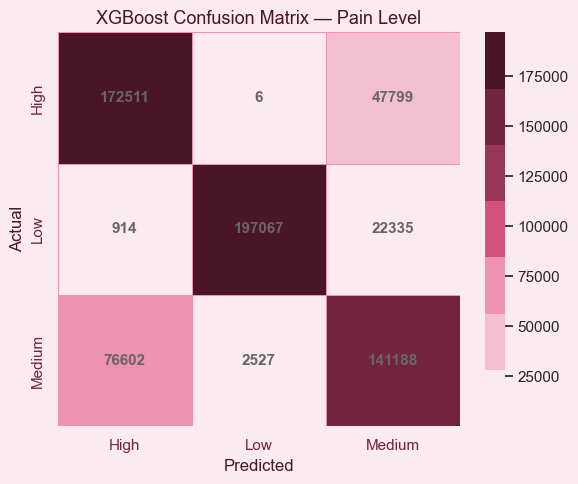

Per-class accuracy:
  High      : 78.3%
  Low       : 89.4%
  Medium    : 64.1%


In [38]:
if xgb_path.exists():
    cm     = np.array(xgb['confusion'])
    labels = [k for k in xgb['report'] if k not in ('accuracy','macro avg','weighted avg')]

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor('#FBEAF0')

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=sns.color_palette(['#FBEAF0','#F4C0D1','#ED93B1','#D4537E','#993556','#72243E','#4B1528'], as_cmap=True),
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        linewidths=0.5,
        linecolor='#ED93B1',
        annot_kws={'color':'#666666','fontsize':11,'fontweight':'bold'}
    )
    ax.set_title('XGBoost Confusion Matrix — Pain Level', fontsize=13, color='#4B1528')
    ax.set_xlabel('Predicted', color='#4B1528')
    ax.set_ylabel('Actual', color='#4B1528')
    ax.tick_params(colors='#72243E')
    ax.set_facecolor('#FBEAF0')
    plt.tight_layout()
    plt.show()

    print('Per-class accuracy:')
    for i, lbl in enumerate(labels):
        acc = cm[i, i] / cm[i].sum() * 100
        print(f'  {lbl:<10}: {acc:.1f}%')